# 深層生成モデル
## EM法の実装

### 目次
##### 1. EMアルゴリズムによる混合ベルヌーイ分布の最適化
##### 2. EMアルゴリズムによる混合ガウス分布の最適化

In [1]:
# 必要なライブラリのインポート

import numpy as np
import matplotlib.pyplot as plt
import random
import copy
from keras.datasets import mnist
import seaborn as sns
import math
from scipy import stats
%matplotlib inline

In [ ]:
# ヘルパー関数の定義

def get_label_idxs(labels: list, t_mnist: np.ndarray) -> np.ndarray:
    """
    指定されたラベルに対応する画像のインデックスを取得する関数
    
    Parameters:
    -----------
    labels : list
        抽出したいラベルのリスト（例：[0, 5, 7]）
    t_mnist : np.ndarray
        MNISTのラベル配列（長さ60000）
    
    Returns:
    --------
    np.ndarray
        指定されたラベルに該当する画像のインデックス配列
    """
    # 長さ60000のt_mnistについて，値が指定したラベルのうちのいずれかであるかのboolean arrayを取ってくる
    label_bool = np.any([t_mnist==label for label in labels], axis=0)
    # Trueである要素のインデックスを得る
    label_idxs = np.where(label_bool)[0]

    return label_idxs


def transforms(data_all: np.ndarray, flatten=True, binarize=True) -> np.ndarray:
    """
    MNIST画像データを前処理する関数
    
    Parameters:
    -----------
    data_all : np.ndarray
        入力画像配列（値の範囲：0-255）
    flatten : bool, default=True
        Trueの場合、2次元の画像を1次元のベクトルに平坦化
    binarize : bool, default=True
        Trueの場合、正規化した値を閾値0.5で0または1のバイナリに変換
    
    Returns:
    --------
    np.ndarray
        前処理された画像配列
        - 値の範囲を0-255から0-1に正規化
        - flattenがTrueの場合：(N, 28, 28) → (N, 784)
        - binarizeがTrueの場合：値が0.5以上で1、未満で0に変換
    """
    # 範囲を0~255から0~1にし，平坦化したあと，閾値0.5で0,1のバイナリにする
    data_all = data_all.astype(np.float64) / 255
    if flatten:
        data_all = data_all.reshape((data_all.shape[0], -1))
    if binarize:
        data_all = (data_all > 0.5).astype(np.uint8)

    return data_all

### 1. EMアルゴリズムによる混合ベルヌーイ分布の最適化

#### 1.1 問題設定

本セクションでは、混合ベルヌーイ分布を用いてMNISTデータセットをモデリングする。
以下ではラベルが 0,5,7 の画像を合わせて1800枚用いる。

観測データ集合は${\bf X}=\left\{{\bf x}_{i}\right\}_{i=1}^{N}$（ただし$N=1800$）．${\bf x}_i$は2値化された$i$枚目の画像（長さ784のベクター)。

$K(=3)$個のラベルのうち，どのラベルの画像の値かを示す**潜在変数**を$\mathbf{z}=\left[z_1, z_2, z_3\right]^{T} \in\{0,1\}^3$とする．

- つまり$\mathbf{z}$は長さ$K$のone-hotベクトルで，${\sum_{k=1}^{K} z_{k}=1},\quad z_k \in \{0,1\}$

- $\mathbf{z} = [1, 0, 0]$ならラベルが0の画像を表す

$\mathbf{z}$が従う確率分布をカテゴリ分布とし，$z_k = 1$となる確率を$\pi_{k}$とする．

- $\sum_{k=1}^{K}\pi_{k}=1\qquad \pi_{k} \in[0,1]$

- カテゴリ分布の確率質量関数　$p_{\pi}(\mathbf{z})=\prod_{k=1}^{K} \pi_{k}^{z_{k}}$

#### 1.2 混合ベルヌーイ分布の復習

ある潜在変数${\bf z}$を選んだ上で，確率変数$x$が従う確率分布は，

$$
p_{\mu}(x|{\bf z}) = \prod_{k=1}^K\left\{ \mu_k^x(1-\mu_k)^{1-x}\right\}^{z_k}
$$

- $z_k=1$となる$k$以外は$z_k=0$となるので，積に影響しない.

同時分布

$$
p_{\mu,\pi}(x,{\bf z}) = p_{\mu}(x|{\bf z})p_{\pi}({\bf z})
= \prod_{k=1}^K \left\{ \pi_k \mu_k^x (1-\mu_k)^{1-x} \right\} ^{z_k}
$$

周辺分布

$$
p_{\mu,\pi}(x) = \sum_z p_{\mu,\pi}(x,{\bf z})
= \sum_{k=1}^K p_{\mu,\pi}(x,z_k=1)
= \sum_{k=1}^K\pi_k\mu_k^x (1-\mu_k)^{1-x}
$$

$x$の周辺分布は，ベルヌーイ分布の線形和で表される．

この対数周辺尤度を最大化するようなパラメータ${\mu_k},{\pi_k}$を求めるために，EMアルゴリズムを用いて最適化を行う．

In [3]:
NUM_SAMPLES = 1800

(x_mnist, t_mnist), _ = mnist.load_data()
# x_mnist: (60000, 28, 28), 訓練用のMNIST画像データ
# t_mnist: (60000,) 訓練用のMNISTラベルデータ
print(f"x_mnist: {x_mnist.shape}, t_mnist: {t_mnist.shape}")

labels = {0, 5, 7}

label_idx = get_label_idxs(labels, t_mnist)

data_all = x_mnist[label_idx][:NUM_SAMPLES]
print(f"data_all: {data_all.shape}")

# 範囲を0~255から0~1にし，平坦化したあと，閾値0.5で0,1のバイナリにする
binary_data = transforms(data_all)
print(f"binary_data: {binary_data.shape}")

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
x_mnist: (60000, 28, 28), t_mnist: (60000,)
data_all: (1800, 28, 28)
binary_data: (1800, 784)


##### 多次元ベルヌーイ分布の対数尤度

一枚の画像について、多次元ベルヌーイ分布の確率質量関数は以下の様になる。
$D$はピクセル数で，MNISTの場合は784．($d$の添字が$\mu$にもついていることに注意.)

$$
p_\mu({\bf x}) = \prod_{d=1}^D\mu_d^{x_d}(1-\mu_d)^{1-{x_d}}
$$

各ピクセルがベルヌーイ分布に従うため、それぞれの確率質量関数を掛け合わせた形になる。

対数をとると，

$$
{\rm log}\ p_\mu({\bf x}) = \sum_{d=1}^D \left\{x_d\ {\rm log\ }\mu_d + (1 - x_d)\ {\rm log\ }(1 - \mu_d)\right\}
$$

In [7]:
def np_log(x):
    """
    数値の安定性を保ため、クリップ値を指定した対数を計算する関数
    
    Parameters:
    -----------
    x : np.ndarray
        対数を取る値
    
    Returns:
    --------
    np.ndarray
        クリップされた値の対数
        
    Notes:
    ------
    float型では1e-323未満の値は精度の関係で0になってしまうため、
    logを取る前に小さい値を1e-323に、大きい値を1e+10に置き換える。
    これによって対数計算でのアンダーフロー/オーバーフローを防ぐ。
    """
    return np.log(np.clip(x, 1e-323, a_max = 1e+10))


def log_bernoulli_density(x, mu):
    """
    ベルヌーイ分布の対数尤度を計算する関数
    
    Parameters:
    -----------
    x : np.ndarray
        観測データ、形状は(N, D)の2値データ（0または1）
        N: サンプル数, D: 特徴次元数
    mu : np.ndarray
        ベルヌーイ分布のパラメータ、形状は(D,)
        各特徴が1となる確率（0～1の値）
    
    Returns:
    --------
    float
        全サンプルの対数尤度の合計
        
    Notes:
    ------
    ベルヌーイ分布の確率質量関数：
    p(x|mu) = mu^x * (1-mu)^(1-x)
    
    対数尤度：
    log p(x|mu) = x*log(mu) + (1-x)*log(1-mu)
    
    この関数は全データ点に対する対数尤度を合計して返す。
    """
    # x: (N, D)の二値データ
    # mu: (D,)のベルヌーイ分布のパラメータ
    # 対数尤度を計算する
    log_p = x * np_log(mu) + (1 - x) * np_log(1 - mu)
    log_p = np.sum(log_p)
    return log_p

#### 1.3 全データに対する、混合ベルヌーイ分布の対数尤度

データ(画像)の数を$N$，混合数を$K$，各ベルヌーイ分布を$p_{\mu_k}(x)$とすると，全データ点に対する混合ベルヌーイ分布の対数尤度は，以下で表さる．

$$
{\rm log}\  p_\mu(X)= \sum_{i=1}^N{\rm log}\sum_{k=1}^K\pi_k p_{\mu_k}({\bf x}_i)
$$
<!--\quad\left( = \sum_{i=1}^N\log\sum_{k=1}^K\pi_k\mu_k^{x_i}(1-\mu_k)^{1-x_i} \right) -->

尤度はそれぞれの画像の確率質量関数を画像の枚数分掛け合わせたものとなるため、対数をとることで画像の枚数分の和に変換される。

In [4]:
def log_likelihood(binary_data, mu_list, pi_list):
    """
    混合ベルヌーイ分布の対数尤度を計算する関数
    
    Parameters:
    -----------
    binary_data : np.ndarray
        観測データ、形状は(N, D)の2値データ（0または1）
        1枚の画像が1次元のベクトルになっている状態(1,784)で、全ての画像がまとめられた配列
        N: サンプル数, D: 特徴次元数
        サイズ: ( 1800, 784 )
    mu_list : list of np.ndarray
        各クラスタのベルヌーイ分布のパラメータのリスト
        各要素は形状(D,)の配列で、各特徴が1となる確率を表す
        潜在変数は3つ(0,5,7)なので、リストの長さは3
        例えば、mu_list[0][100] = 0.8 なら
        「ラベル0の画像では、ピクセル100番目が白（1）になる確率が80%」
        サイズ:  [ (784), (784), (784) ]
    pi_list : list of float
        各クラスタの混合係数のリスト
        各要素は0～1の値で、全ての要素の合計は1になる
        pi_list[0] = 0.3 なら「全体の30%がラベル0の画像」
        サイズ: ( 3, )
    """
    log_likely_all = 0
    for data in binary_data:
        likely = 0
        for k in range(len(pi_list)):
             likely += pi_list[k] * np.exp(log_bernoulli_density(data, mu_list[k]))
        log_likely_all += np_log(likely)

    return log_likely_all

#### 1.4 負担率（Responsibility）

**直感的な理解：**

負担率は、答案を見ていない状態で「この画像は、のラベル0（数字の0）からサンプリングされた確率はどのくらい？」という問いに対する答えです。

例えば、ある画像$\mathbf{x}_i$に対して：
- $\gamma(z_{i1}=1) = 0.8$ → 80%の確信度で「この画像はラベル0」
- $\gamma(z_{i2}=1) = 0.1$ → 10%の確信度で「この画像はラベル5」  
- $\gamma(z_{i3}=1) = 0.1$ → 10%の確信度で「この画像はラベル7」

（必ず合計は1.0になります）

負担率を計算することは、各データ点がどのカテゴリからサンプリングされたかを推論することに相当します。

**数学的定義：**

$i$番目のデータ(画像)に対する、$k$番目の潜在変数$z_{ik}$の負担率は以下で表されます：

$$
p_{\mu,\pi}(z_{ik}=1 | \mathbf{x}_i)
= \frac{p_{\mu,\pi}(\mathbf{x}_i,z_{ik}=1)}{\sum_{z} p_{\mu,\pi}(\mathbf{x}_i, z_{ik}=1)}
=\frac{\pi_k\ p_{\mu_k}(\mathbf{x}_i)}{\sum_{j=1}^K\pi_j\ p_{\mu_j}(\mathbf{x}_i)}
\equiv \gamma(z_{ik})
$$

**分子の意味：** $\pi_k p_{\mu_k}(\mathbf{x}_i)$

これは以下の2つの確率の積です：

- $\pi_k$ ：全データの中でクラス$k$が占める割合（事前確率）
  
- $p_{\mu_k}(\mathbf{x}_i)$ ：クラス$k$のパラメータ$\mu_k$で、この画像$\mathbf{x}_i$が生成される確率（尤度）

**つまり、分子は「クラス$k$かつこの特定の画像$\mathbf{x}_i$が出現する同時確率」** を表します。

言い換えると、「全ランダムサンプリング中で、クラス$k$から選ばれて、かつこのような画像が出る確率」です。

例：
$π_1=0.33$ (全体の33%）、
$p_{μ1}(x_i)=0.6$（このパターンのクラス1での確率）なら
→ 分子 = 0.33 × 0.6 = 0.198 = 約20%の確率で「クラス1からこんな画像が出る」

**分母**：$\sum_{j=1}^K \pi_j p_{\mu_j}(\mathbf{x}_i)$

全クラスについて同時確率の合計 → 正規化定数（確率の合計を1にするため）

つまり：

$$\gamma(z_{ik}=1) = \frac{\text{「クラス$k$かつ画像$\mathbf{x}_i$」の確率}}{\text{「いずれかのクラス かつ 画像$\mathbf{x}_i$」の確率}}$$

分子がどのクラスからこの画像が来たかの「強さ」を、分母で「競争」させて相対的な確信度を求めています。

In [5]:
def responsibility(data_all, mu_list, pi_list):
    """
    各データ点に対する負担率（responsibility）を計算する関数

    Parameters:
    -----------
    data_all : np.ndarray
        観測データ。形状は (N, D) の2値データ
        N: サンプル数, D: 特徴次元数
    mu_list : list of np.ndarray
        各クラスタのベルヌーイ分布パラメータのリスト
        各要素の形状は (D,)
    pi_list : np.ndarray or list
        各クラスタの混合係数（事前確率）
        要素数はクラスタ数K、合計は1

    Returns:
    --------
    np.ndarray
        負担率行列 gamma_mat（形状: (N, K)）
        gamma_mat[i, k] は「データiがクラスタkに属する事後確率」

    Notes:
    ------
    数値安定性のため、expの前に各データ点ごとに最大値を引いて正規化している。
    """
    gamma_mat = np.zeros((data_all.shape[0], len(pi_list)))  # (N, K)
    for i in range(gamma_mat.shape[0]):
        for k in range(gamma_mat.shape[1]):
            gamma_mat[i][k] = log_bernoulli_density(data_all[i], mu_list[k])
        gamma_mat[i] -= np.max(gamma_mat[i])
        gamma_mat[i] = pi_list * np.exp(gamma_mat[i])
        gamma_mat[i] /= np.sum(gamma_mat[i])
    return gamma_mat

#### 1.5 学習（EMアルゴリズムの詳細）

EMアルゴリズムは、潜在変数 $\mathbf{z}$ を直接観測できないモデルで、
対数尤度

$$
\log p(X|\mu,\pi)=\sum_{i=1}^{N}\log\sum_{k=1}^{K}\pi_k p_{\mu_k}(\mathbf{x}_i)
$$

を最大化するための反復最適化法です。

混合ベルヌーイ分布では、パラメータは
- $\pi_k$：クラスタ $k$ の混合比
- $\mu_k$：クラスタ $k$ のベルヌーイパラメータ（各ピクセルが1になる確率）

です。

学習は以下を繰り返します。

1. Eステップ（Expectation）
現在のパラメータ $(\mu,\pi)$ を固定し、各データ点が各クラスタに属する事後確率（負担率）を計算します。

$$
\gamma(z_{ik}) = p(z_{ik}=1|\mathbf{x}_i,\mu,\pi)
=\frac{\pi_k p_{\mu_k}(\mathbf{x}_i)}{\sum_{j=1}^{K}\pi_j p_{\mu_j}(\mathbf{x}_i)}
$$

ここで $\gamma(z_{ik})$ は「画像 $i$ がクラスタ $k$ に属する確信度」です。

2. Mステップ（Maximization）
Eステップで得た $\gamma$ を固定し、期待完全データ対数尤度を最大にするようにパラメータを更新します。

$$
N_k=\sum_{i=1}^{N}\gamma(z_{ik}),\qquad
\hat\pi_k=\frac{N_k}{N},\qquad
\hat\mu_k=\frac{1}{N_k}\sum_{i=1}^{N}\gamma(z_{ik})\mathbf{x}_i
$$

- $N_k$：クラスタ $k$ に割り当てられた有効サンプル数（ソフトなカウント）
- $\hat\pi_k$：クラスタ比率の更新
- $\hat\mu_k$：負担率で重み付けした平均画像（各次元ごと）

なぜこの更新式になるか：
- 直接最大化したいのは $\log p(X|\mu,\pi)$ ですが、潜在変数の和 $\log\sum_k(\cdot)$ があるため解きにくい
- EMでは補助関数
$$
Q(\mu,\pi)=\mathbb{E}_{Z|X,\mu^{old},\pi^{old}}[\log p(X,Z|\mu,\pi)]
$$
を使い、Eステップでこの期待値の重み $\gamma(z_{ik})$ を計算する
- Mステップではこの $Q$ を $\mu,\pi$ について最大化する。すると
  - $\pi$ は「確率の和が1」という制約付き最適化になり、ラグランジュ未定乗数法で $\hat\pi_k=N_k/N$
  - $\mu_k$ は各次元ごとに重み付きベルヌーイ最尤推定となり、$\hat\mu_k=(\sum_i\gamma_{ik}x_i)/(\sum_i\gamma_{ik})$
- つまり更新式は、"負担率を重みとした最尤推定" をそのまま解いた結果です

導出ミニ版（1次元ベルヌーイ）：
- $Q$ の $\mu_k$ に関する部分は
$$
Q_k(\mu_k)=\sum_i\gamma_{ik}\{x_i\log\mu_k+(1-x_i)\log(1-\mu_k)\}
$$
- これを $\mu_k$ で微分して0に置くと
$$
\frac{\partial Q_k}{\partial \mu_k}=\sum_i\gamma_{ik}\left(\frac{x_i}{\mu_k}-\frac{1-x_i}{1-\mu_k}\right)=0
\Rightarrow
\mu_k=\frac{\sum_i\gamma_{ik}x_i}{\sum_i\gamma_{ik}}
$$
- 多次元の場合も各次元 $d$ で独立に同じ形になり、式をベクトル化したものが上の更新式

ELBO（Evidence Lower BOund）との関係：
- 任意の分布 $q(Z)$ に対して、対数尤度は
$$
\log p(X|\mu,\pi)=\mathcal{L}(q,\mu,\pi)+\mathrm{KL}\bigl(q(Z)\|p(Z|X,\mu,\pi)\bigr)
$$
と分解できる
- ここで
$$
\mathcal{L}(q,\mu,\pi)=\mathbb{E}_{q(Z)}[\log p(X,Z|\mu,\pi)]-\mathbb{E}_{q(Z)}[\log q(Z)]
$$
がELBO（下界）で、KLは常に0以上なので $\mathcal{L}\le \log p(X|\mu,\pi)$

EMとの対応：
- Eステップ：$q(Z)$ を真の事後分布 $p(Z|X,\mu^{old},\pi^{old})$ に置く
  - このとき KL = 0 となり、ELBOは現在パラメータで対数尤度と一致
- Mステップ：その $q$ を固定して $\mathcal{L}(q,\mu,\pi)$ を最大化
  - ELBOが上がるため、結果として対数尤度も非減少になる

要するにEMは、「Eステップで下界をタイトにし、Mステップでその下界を押し上げる」ことを交互に行うアルゴリズムです。

3. 収束判定
更新前後の対数尤度の差

$$
\Delta = \log p(X|\mu^{new},\pi^{new})-\log p(X|\mu^{old},\pi^{old})
$$

がしきい値 $\varepsilon$ 以下になったら終了します（または最大反復回数で停止）。

実装上の注意：
- Eステップでは指数計算の前に最大値を引くなど、数値安定化が重要
- 初期値により収束先（局所解）が変わるため、複数初期値で試すのが実務的
- EMは各反復で対数尤度を非減少にするため、学習の進行を尤度曲線で確認しやすい

> [!NOTE]
> **補足: ELBOとEMアルゴリズムの関係**
>
> 対数尤度は、任意の分布 $q(Z)$ を使って次のように分解できます。
>
> $$
> \log p(X|\mu,\pi)=\mathcal{L}(q,\mu,\pi)+\mathrm{KL}\bigl(q(Z)\|p(Z|X,\mu,\pi)\bigr)
> $$
>
> ここで
>
> $$
> \mathcal{L}(q,\mu,\pi)
> =\mathbb{E}_{q(Z)}[\log p(X,Z|\mu,\pi)]-\mathbb{E}_{q(Z)}[\log q(Z)]
> $$
>
> がELBO（Evidence Lower BOund）です。KL項は常に $\ge 0$ なので、
> ELBOは対数尤度の下界になります。
>
> EMはこれを次の2段で最適化しています。
>
> 1. **Eステップ**: $q(Z)=p(Z|X,\mu^{old},\pi^{old})$ と置く
>    - このときKLが0になり、ELBOは現在パラメータで対数尤度に一致
>
> 2. **Mステップ**: $q$ を固定して $\mathcal{L}(q,\mu,\pi)$ を最大化
>    - ELBOが増加し、対数尤度も非減少になる
>
> つまりEMは、
> **「Eステップで下界をタイトにする」→「Mステップでその下界を押し上げる」**
> を繰り返すアルゴリズムです。

Iteration: 0, log_likelihood: -734.3689618035753


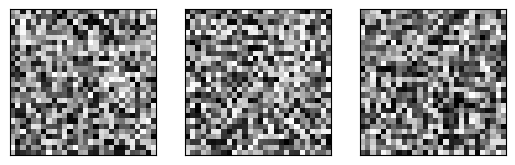

Iteration: 1, log_likelihood: -196.3950287362405
pi_list: [0.5708701353717864, 0.0009882088258831125, 0.4281416558023305]


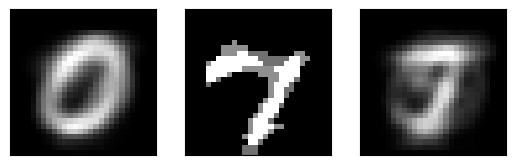

Iteration: 2, log_likelihood: -189.31500848266393
pi_list: [0.49069683345868387, 0.001665868839029956, 0.5076372977022863]


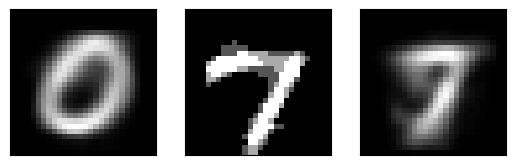

Iteration: 3, log_likelihood: -188.50275083448096
pi_list: [0.46910778651170026, 0.0016666666666666663, 0.529225546821633]


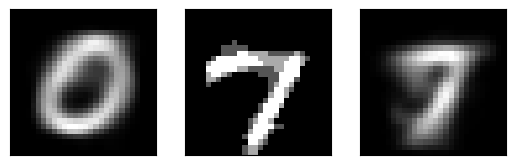

Iteration: 4, log_likelihood: -188.39092821361297
pi_list: [0.46534217937232325, 0.0016666666666666668, 0.53299115396101]


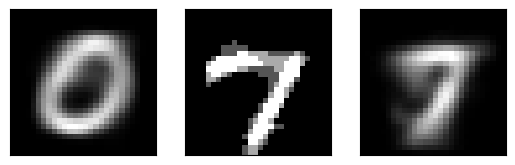

Iteration: 5, log_likelihood: -188.3626249471432
pi_list: [0.46640001203265763, 0.0016666666666666668, 0.5319333213006757]


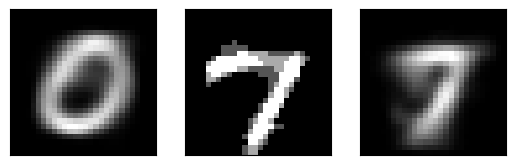

Iteration: 6, log_likelihood: -188.35651788824865
pi_list: [0.46870090989250285, 0.0016666666666666668, 0.5296324234408305]


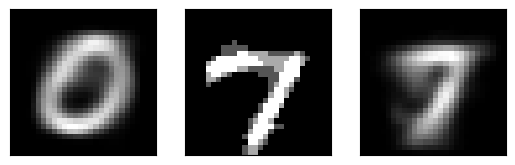

Iteration: 7, log_likelihood: -188.3551512308181
pi_list: [0.47016550078435987, 0.0016666666666666668, 0.5281678325489735]


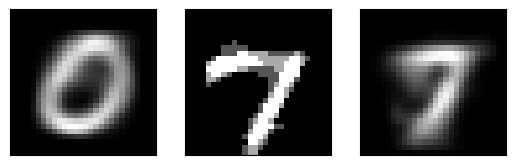

Iteration: 8, log_likelihood: -188.35452042465377
pi_list: [0.47114840618937837, 0.0016666666666666668, 0.5271849271439549]


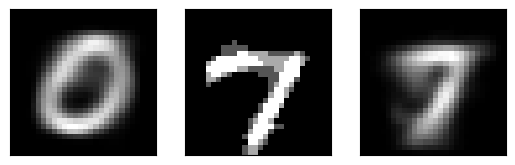

Iteration: 9, log_likelihood: -188.35424522195527
pi_list: [0.47180954281133886, 0.0016666666666666668, 0.5265237905219944]


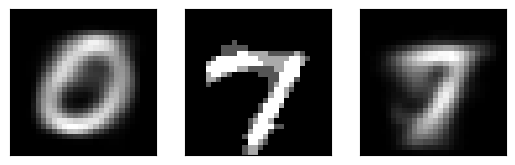

Iteration: 10, log_likelihood: -188.35410313979148
pi_list: [0.4722697318658981, 0.0016666666666666668, 0.5260636014674352]


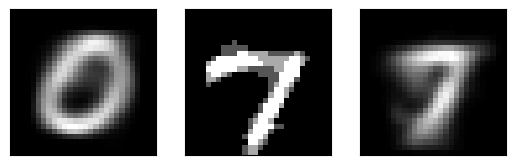

Iteration: 11, log_likelihood: -188.3540093258142
pi_list: [0.47261892997364535, 0.0016666666666666668, 0.5257144033596879]


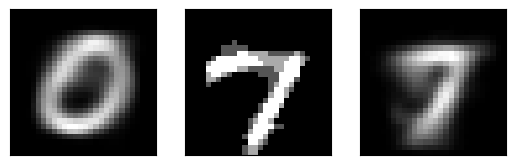

Iteration: 12, log_likelihood: -188.3539308013157
pi_list: [0.47291068234803246, 0.0016666666666666668, 0.5254226509853008]


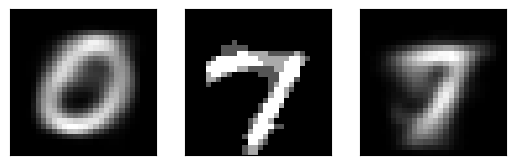

Iteration: 13, log_likelihood: -188.35385316704287
pi_list: [0.47317566305338127, 0.0016666666666666668, 0.525157670279952]


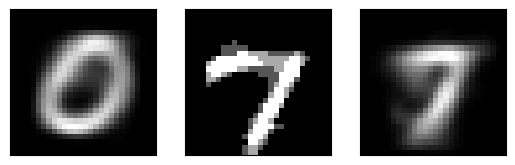

Iteration: 14, log_likelihood: -188.35377558446393
pi_list: [0.4734273200659971, 0.0016666666666666668, 0.5249060132673362]


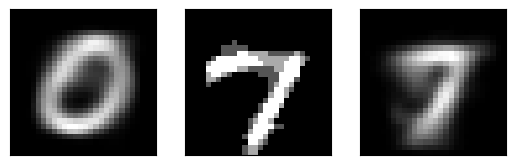

Iteration: 15, log_likelihood: -188.35371152491447
pi_list: [0.47366065038680705, 0.0016666666666666663, 0.5246726829465262]


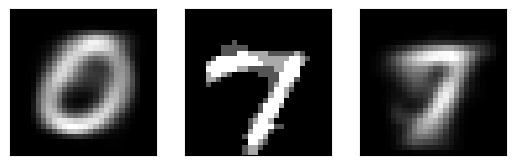

Iteration: 16, log_likelihood: -188.35367240799764
pi_list: [0.47385812336005656, 0.0016666666666666668, 0.5244752099732768]


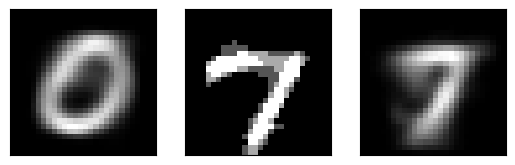

Iteration: 17, log_likelihood: -188.35365327750253
pi_list: [0.4740084990335514, 0.0016666666666666668, 0.5243248342997819]


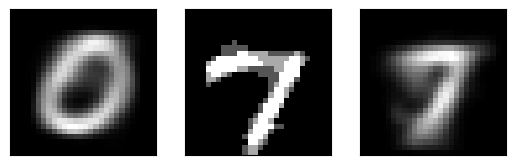

Iteration: 18, log_likelihood: -188.3536446407675
pi_list: [0.47411480863307676, 0.0016666666666666668, 0.5242185247002565]


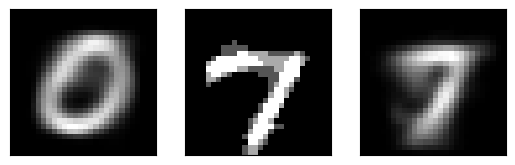

Iteration: 19, log_likelihood: -188.35364085734304
pi_list: [0.474186780156898, 0.0016666666666666668, 0.5241465531764352]


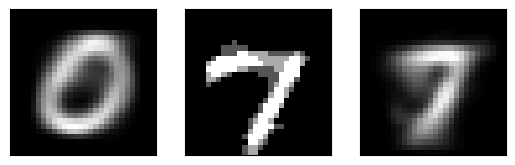

Iteration: 20, log_likelihood: -188.35363924669258
pi_list: [0.47423423219986943, 0.0016666666666666668, 0.5240991011334639]


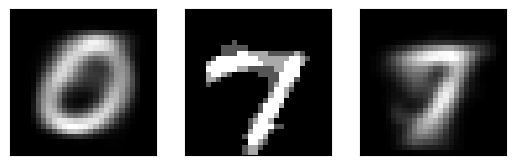

Iteration: 21, log_likelihood: -188.3536385781054
pi_list: [0.47426498015291396, 0.0016666666666666668, 0.5240683531804193]


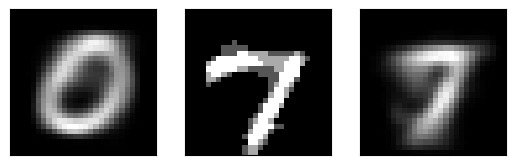

In [8]:
# 各ベルヌーイ分布のパラメータを適当な値で初期化
mu_list = [np.random.rand(binary_data.shape[1]) for _ in labels] # それぞれ ( 784, )

# 混合分布の重みを初期化
pi_list = [0.3, 0.3, 0.4]

n_iter = 0

# 現在のパラメータを用いて全データに対する対数尤度を計算
likely = log_likelihood(binary_data, mu_list, pi_list) / binary_data.shape[0]
print('Iteration: {0}, log_likelihood: {1}'.format(n_iter, likely))

fig = plt.figure()
for i in range(len(mu_list)):
    ax = fig.add_subplot(1, len(mu_list), i+1, xticks=[], yticks=[])
    ax.imshow(mu_list[i].reshape(28, 28), 'gray')
plt.show()

# 対数尤度の上がり幅がth以下になったら収束したと判定する
th = 0.001

# 学習
while True:
    n_iter += 1

    # Eステップ：現在のパラメータのもとでの事後分布（負担率）を計算
    gamma_mat = responsibility(binary_data, mu_list, pi_list) # ( 1800, 3 )
    n_k = np.sum(gamma_mat, axis=0) # ( 3, )

    # Mステップ：負担率を用いて，新しいパラメータを推定・更新
    # piの新しい推定量
    pi_list_next = (n_k / n_k.sum()).tolist()

    # gamma_mat: ( 1800, 3 ) binary_data: ( 1800, 784 ) n_k: ( 3, )
    mu_list_next = (gamma_mat.T @ binary_data) / n_k[:, np.newaxis] # ( 3, 784 )

    # muの新しい推定量．0次元目だけリストになる
    mu_list_next = list(mu_list_next) # [( 784, ), ( 784, ), ( 784, )]

    mu_list = copy.deepcopy(mu_list_next)
    pi_list = copy.deepcopy(pi_list_next)

    likely_before = likely.copy()

    likely = log_likelihood(binary_data, mu_list, pi_list) / binary_data.shape[0]

    print('Iteration: {0}, log_likelihood: {1}'.format(n_iter, likely))

    delta = likely - likely_before

    print('pi_list: {}'.format(pi_list))
    # print("mu_list avg: {}".format([mu.mean() for mu in mu_list]))

    fig = plt.figure()
    for i in range(len(mu_list)):
        ax = fig.add_subplot(1, len(mu_list), i+1, xticks=[], yticks=[])
        ax.imshow(mu_list[i].reshape(28, 28), 'gray')
    plt.show()

    if delta < th and n_iter > 20:
        break

最後に最適化したパラメータのベルヌーイ分布からサンプリングを行う

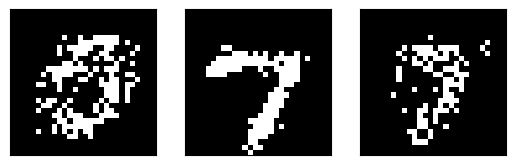

In [9]:
sampled_data = [np.random.binomial(n=1, p=mu) for mu in mu_list]

fig = plt.figure()
for i, sample in enumerate(sampled_data):
    ax = fig.add_subplot(1, len(mu_list), i+1, xticks=[], yticks=[])
    ax.imshow(sample.reshape(28, 28), 'gray')
plt.show()

### 2. EMアルゴリズムによる混合ガウス分布の最適化

#### 2.1 問題設定

本セクションで用いるデータは，人工的に生成した2次元混合ガウス分布によるデータ．

先ほどの混合ベルヌーイ分布ではデータは784次元だが，今回2次元データを用いるのは，各学習ステップにおける分布の変化をわかりやすく可視化するため．

In [10]:
#データ分布（混合ガウス分布）を定義してデータを生成する

mu0_data = np.array([0, -0.5])
sigma0_data = np.array([[1.0, 0], [0, 1.0]])

mu1_data = np.array([2.5, 2])
sigma1_data = np.array([[0.5, 0.3], [0.3, 0.7]])

mu2_data = np.array([-2, 1.5])
sigma2_data = np.array([[1.2, 0.2], [0.2, 0.4]])

mu_data_list = [mu0_data, mu1_data, mu2_data]
sigma_data_list = [sigma0_data, sigma1_data, sigma2_data]
sigma_data_inv_list = [np.linalg.inv(sigma) for sigma in sigma_data_list]
sigma_data_det_list = [np.linalg.det(sigma) for sigma in sigma_data_list]

pi_data_list = [0.45, 0.25, 0.3]


NUM_DATA = 3000

# 各データをどのガウス分布からサンプリングしてくるか．set {0, 1, 2}
categories = np.random.randint(len(pi_data_list), size=NUM_DATA) # ( 3000, )

data_all = []
for c in categories:
    data_all.append(
        np.random.multivariate_normal(
            mu_data_list[c], sigma_data_list[c]
        )
    )
data_all = np.stack(data_all) # [(2,), (2,).... (2,)] -> ( 3000, 2 )

print(f"data_all: {data_all.shape}")

data_all: (3000, 2)


#### 多次元ガウス分布の確率密度関数

D次元データに対するガウス分布の確率密度関数は以下で表される．

$$
p_{\mu,\Sigma}({\bf x})
= \frac{1}{\sqrt{(2\pi)^D|\Sigma|}}{\rm exp}\left\{-\frac{1}{2}({\bf x} - {\bf \mu})^T \Sigma^{-1}({\bf x} - {\bf \mu})\right\}
\equiv N({\bf x}; {\bf \mu}, \Sigma)
$$

In [ ]:
# 一つのデータ点に対してガウス分布の尤度を計算する関数
def gaussian_density(x, mu, sigma_inv, sigma_det):
    """
    多次元ガウス分布の確率密度を1データ点に対して計算する関数

    Parameters:
    -----------
    x : np.ndarray
        観測データ点。形状は (D,)
    mu : np.ndarray
        平均ベクトル。形状は (D,)
    sigma_inv : np.ndarray
        共分散行列の逆行列。形状は (D, D)
    sigma_det : float
        共分散行列の行列式

    Returns:
    --------
    float
        ガウス分布 N(x; mu, Sigma) の確率密度値
    """
    # x: ( 2, ) mu: ( 2, ) sigma_inv: ( 2, 2 ) sigma_det: ()
    diff = x - mu
    z = np.exp(-np.dot(diff, np.dot(sigma_inv, diff.T)) / 2)
    p = z / np.sqrt((np.power(2*np.pi, sigma_inv.shape[0]) * sigma_det))
    return p

混合ガウス分布の周辺分布も，混合ベルヌーイ分布と同じように，ガウス分布の線形和になります．

$$
p_{{\bf \mu},\Sigma}({\bf x}) = \sum_{k=1}^K \pi_k \mathcal{N}({\bf x}; {\bf \mu}_k,\Sigma_k)
\qquad \sum_{k=1}^K\pi_k = 1
$$

以下では，データ生成に用いた混合ガウス分布の確率密度関数と，実際に生成されたデータ点(の一部)を可視化します．

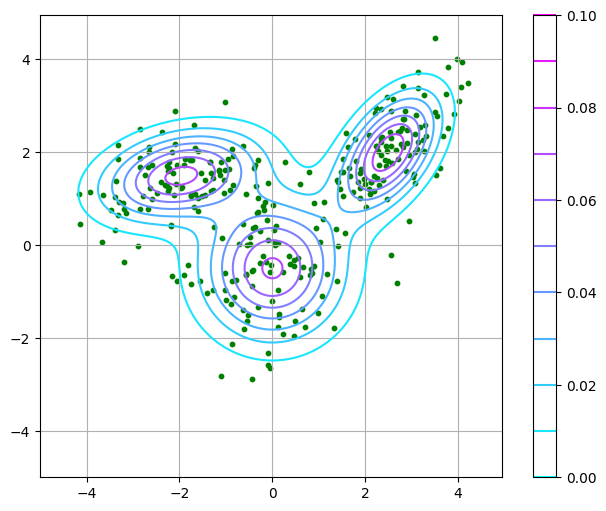

In [12]:
# データ分布とデータ点の可視化
NUM_SAMPLES = 300

x = np.arange(-5, 5, 0.05) # x軸
y = np.arange(-5, 5, 0.05) # y軸

X, Y = np.meshgrid(x, y) # ともに ( 200, 200 )

Z = np.zeros_like(X)
for num in range(len(pi_data_list)):
    # すべての格子点についてまとめてdensityを計算するとメモリ不足になる
    for i in range(X.shape[0]):
        for j in range(Y.shape[1]):
            Z[i][j] += pi_data_list[num] * gaussian_density(
                np.array([X[i][j], Y[i][j]]),
                mu_data_list[num],
                sigma_data_inv_list[num],
                sigma_data_det_list[num]
            )

fig, ax = plt.subplots(figsize=(8.0, 6.0))
cont10 = ax.contour(X, Y, Z, levels=[0.01*i for i in range(11)], cmap='cool')

data_plot = plt.scatter(data_all.T[0, :NUM_SAMPLES], data_all.T[1, :NUM_SAMPLES], s=10, c='g')
ax.set_aspect('equal','box')
plt.colorbar(cont10)
plt.grid(True)
plt.show()

In [13]:
# 全データ点に対する、混合ガウス分布の対数尤度を計算する関数
def log_likelihood(data_all, mu_list, sigma_list, pi_list): # data_all: ( 3000, 2 )
    """
    各データ点 x_i に対して
    log(sum_k pi_k * N(x_i | mu_k, Sigma_k))
    を計算し、その総和を返す。

    Parameters
    ----------
    data_all : np.ndarray
        観測データ。形状は (N, D)
    mu_list : list[np.ndarray]
        各クラスタの平均ベクトルのリスト。各要素は (D,)
    sigma_list : list[np.ndarray]
        各クラスタの共分散行列のリスト。各要素は (D, D)
    pi_list : list[float] or np.ndarray
        各クラスタの混合係数。要素数は K、総和は1

    Returns
    -------
    float
        全データに対する対数尤度の合計
    """
    sigma_inv_list = [np.linalg.inv(sigma) for sigma in sigma_list]
    sigma_det_list = [np.linalg.det(sigma) for sigma in sigma_list]

    log_likely_all = 0.0
    for data in data_all:
        likely = 0.0
        for k in range(len(pi_list)):
            likely += pi_list[k] * gaussian_density(
                data, mu_list[k], sigma_inv_list[k], sigma_det_list[k]
            )
    log_likely_all += np.log(likely)

    return log_likely_all

#### 2.3 負担率

負担率も混合ベルヌーイ分布の場合と同様に，

$i$番目のデータ点に対する，$k$番目の潜在変数$z_{ik}$とすると，負担率は，

$$
p_{{\bf \mu},\Sigma,\pi}(z_{ik}=1|{\bf x}_i)
= \frac{\pi_k\ N({\bf x}_i; {\bf \mu}_k, \Sigma_k)}{\sum_{j=1}^K\pi_j\ N({\bf x}_i; {\bf \mu}_j, \Sigma_j)}
\equiv \gamma(z_{ik})
$$

で表されます．

In [14]:
# 負担率を計算する関数
def responsibility(data_all, mu_list, sigma_list, pi_list):
    """
    学習中の混合ガウス分布を可視化する関数。

    何をしているか:
    - 2次元グリッド上で、現在のパラメータに基づく混合密度を計算する
    - 密度を等高線として描画する
    - 観測データの一部と、各クラスタ中心（平均ベクトル）を重ねて表示する
    - タイトルに反復回数 n_iter を表示し、学習の進行を追跡できるようにする

    Parameters
    ----------
    data_all : np.ndarray
        観測データ。形状は (N, D)
    mu_list : list of np.ndarray
        各クラスタの平均ベクトルのリスト
    sigma_inv_list : list of np.ndarray
        各クラスタ共分散行列の逆行列リスト
    sigma_det_list : list of float
        各クラスタ共分散行列の行列式リスト

    Returns
    -------
    None
        図を表示する（戻り値は返さない）
    """
    sigma_inv_list = [np.linalg.inv(sigma) for sigma in sigma_list]
    sigma_det_list = [np.linalg.det(sigma) for sigma in sigma_list]

    gamma_mat = np.zeros((data_all.shape[0], len(pi_list))) # ( 3000, 3 )
    for i in range(gamma_mat.shape[0]):
        for k in range(gamma_mat.shape[1]):
            gamma_mat[i][k] = pi_list[k] * gaussian_density(data_all[i], mu_list[k], sigma_inv_list[k], sigma_det_list[k])
        gamma_mat[i] /= np.sum(gamma_mat[i])
    return gamma_mat

In [ ]:
#学習時の可視化を行う関数

def visualization(data_all, mu_list, sigma_inv_list, sigma_det_list):
    """
学習中の混合ガウス分布を可視化する関数。

何をしているか:
- 2次元グリッド上で、現在のパラメータに基づく混合密度を計算する
- 密度を等高線として描画する
- 観測データの一部と、各クラスタ中心（平均ベクトル）を重ねて表示する
- タイトルに反復回数 n_iter を表示し、学習の進行を確認できるようにする

Parameters
----------
data_all : np.ndarray
    観測データ。形状は (N, D)
mu_list : list[np.ndarray]
    各クラスタの平均ベクトルのリスト
sigma_inv_list : list[np.ndarray]
    各クラスタ共分散行列の逆行列リスト
sigma_det_list : list[float]
    各クラスタ共分散行列の行列式リスト

Returns
-------
None
    図を表示する（戻り値は返さない）
"""
    x = np.arange(-5, 5, 0.05) # x軸
    y = np.arange(-5, 5, 0.05) # y軸

    X, Y = np.meshgrid(x, y)
    Z = np.zeros_like(X)
    for num in range(len(pi_data_list)):
        for i in range(X.shape[0]):
            for j in range(Y.shape[1]):
                Z[i][j] += pi_list[num] * gaussian_density(np.array([X[i][j], Y[i][j]]), mu_list[num], sigma_inv_list[num], sigma_det_list[num])

    fig, ax = plt.subplots(figsize=(6.0, 4.5))
    data_plot = ax.scatter(data_all.T[0][0:300], data_all.T[1][0:300], s=7, c='g')

    for k in range(len(mu_list)):
        ax.scatter(mu_list[k][0], mu_list[k][1], s=60, c='r', marker='x')

    ax.set_aspect('equal','box')
    cont10 = ax.contour(X, Y, Z, levels=[0.01*i for i in range(11)], cmap='cool')

    plt.colorbar(cont10)
    plt.title("step:{}".format(n_iter))
    plt.grid(True)

    plt.show()

### 2.4 学習

混合ガウス分布に対しても，EMアルゴリズムの基本的な流れは混合ベルヌーイ分布の場合と同じです．しかし，Mステップにおけるパラメータの更新において，共分散行列の更新も行う必要があります．

更新式は以下で表されます（証明等は[こちら](https://qiita.com/kenmatsu4/items/59ea3e5dfa3d4c161efb)などを参照してください）．

$$
\hat{\pi}_k = \frac{N_k}{N}
$$

$$
\hat{\bf \mu}_k = \frac{1}{N_k}\sum_{i=1}^N\gamma(z_{ik}){\bf x}_i
$$

$$
\hat{\Sigma}_k = \frac{1}{N_k}\sum_{i=1}^N\gamma(z_{ik})({\bf x}_i - \hat{\bf \mu}_k)({\bf x}_i - \hat{\bf \mu}_k)^T
$$

$$
ただし，
N_k = \sum_{n=1}^N\gamma(z_{ik})
$$

$\hat{\pi}_k$は全データの負担率の平均値，$\hat{\bf \mu}_k$は各データ点の負担率による重み付き平均値，$\hat{\Sigma}_k$は各データ点の負担率による重み付き共分散に相当します．


Iteration: 0, log_likelihood: -6.18980447368549


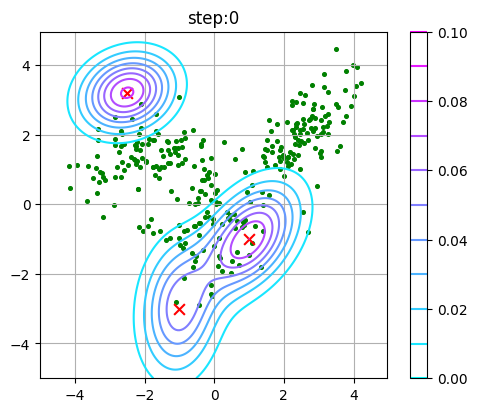

Iteration: 1, log_likelihood: -3.5266988170735307


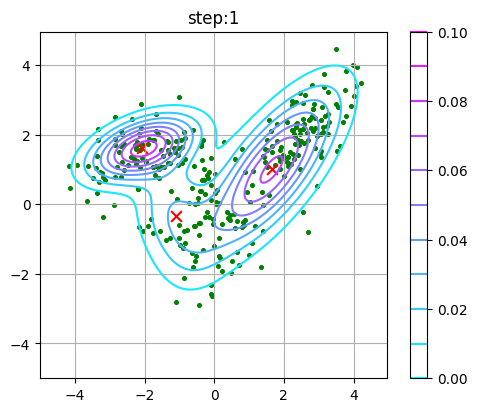

Iteration: 2, log_likelihood: -3.5077160164373216


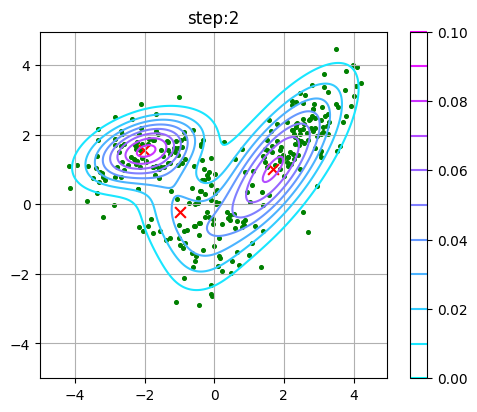

Iteration: 3, log_likelihood: -3.4995141983655405


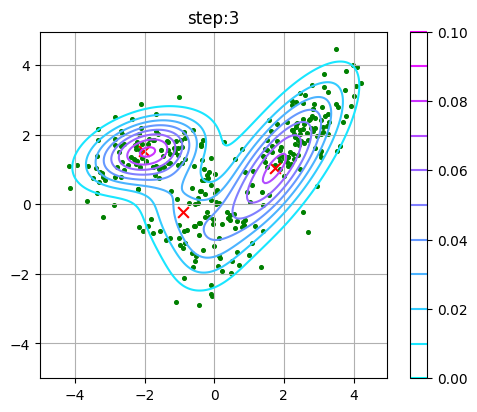

Iteration: 4, log_likelihood: -3.493670641334029


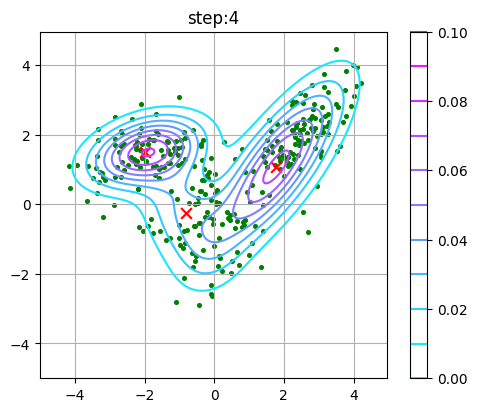

Iteration: 5, log_likelihood: -3.48858252301198


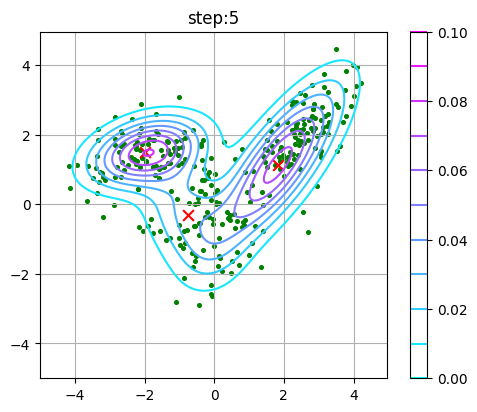

Iteration: 6, log_likelihood: -3.4839227526837173


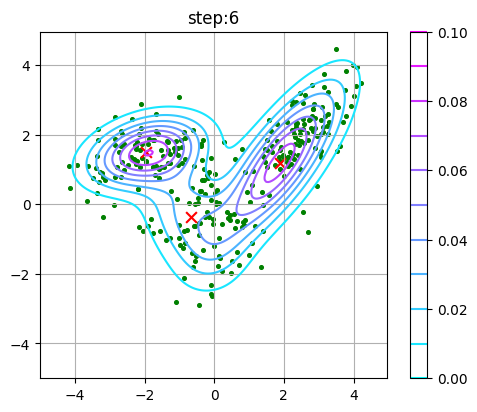

Iteration: 7, log_likelihood: -3.4795211981785186


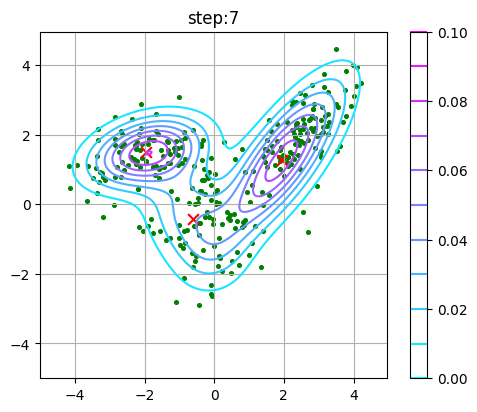

Iteration: 8, log_likelihood: -3.4752134278313824


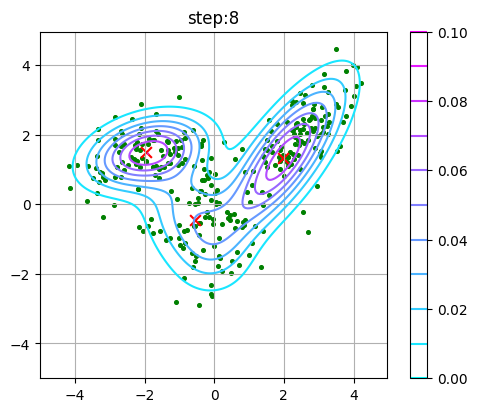

Iteration: 9, log_likelihood: -3.470866439769613


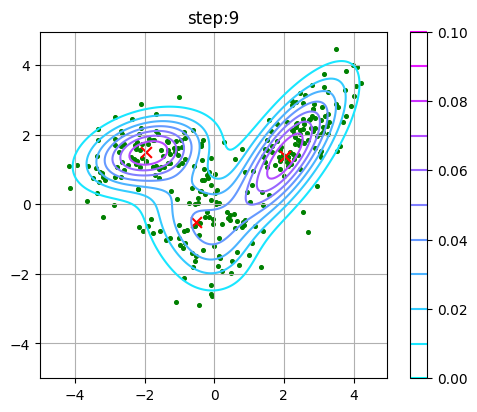

Iteration: 10, log_likelihood: -3.4664060523512163


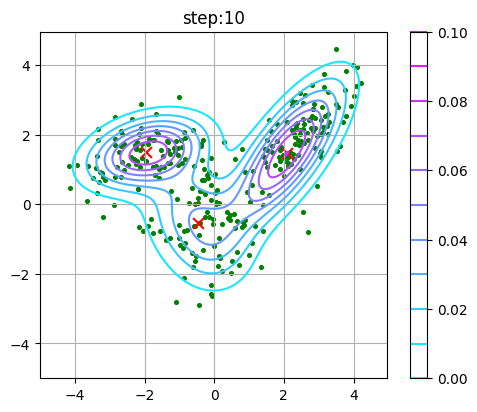

Iteration: 11, log_likelihood: -3.4618349522712486


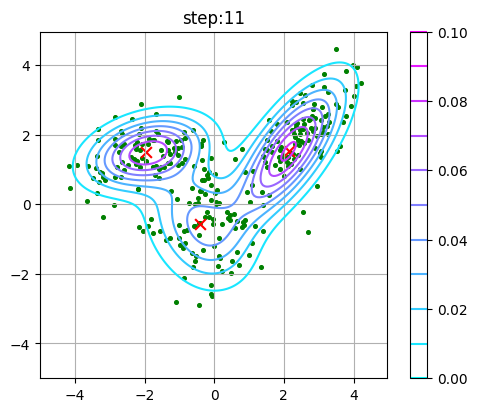

Iteration: 12, log_likelihood: -3.4572391816851322


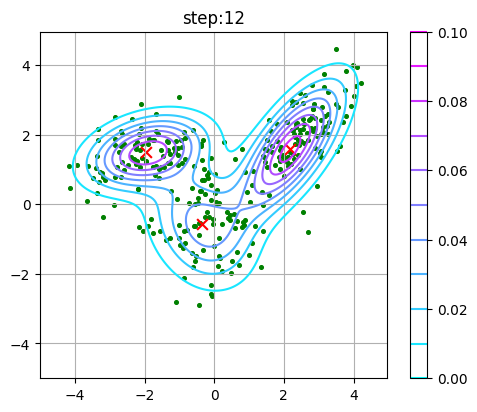

Iteration: 13, log_likelihood: -3.4527792827020822


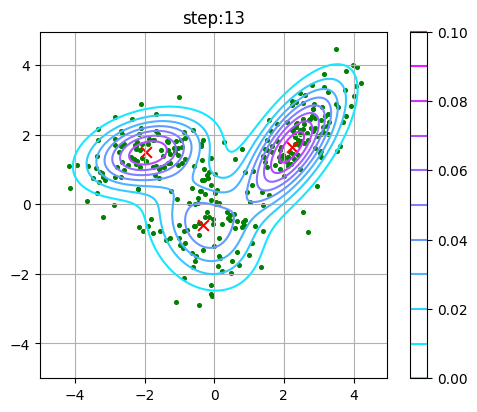

Iteration: 14, log_likelihood: -3.4486614549006536


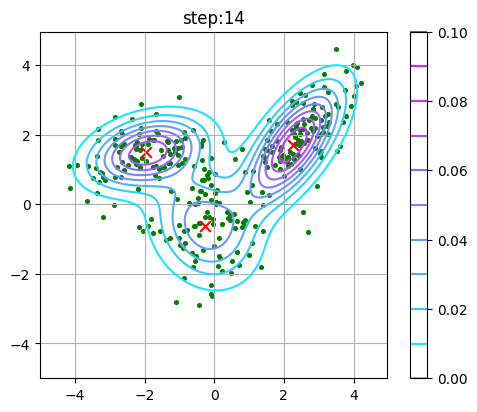

Iteration: 15, log_likelihood: -3.4450862678837413


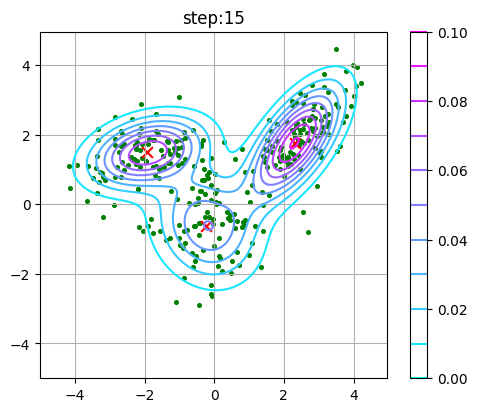

Iteration: 16, log_likelihood: -3.442186344303408


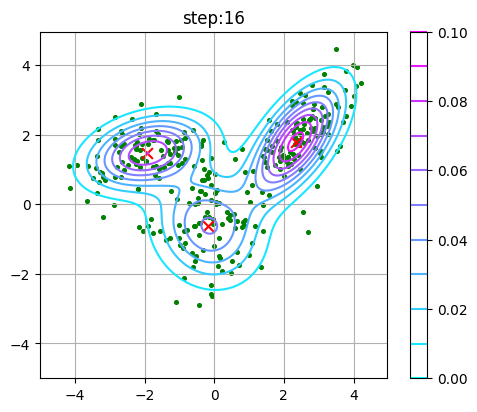

Iteration: 17, log_likelihood: -3.4399851988655628


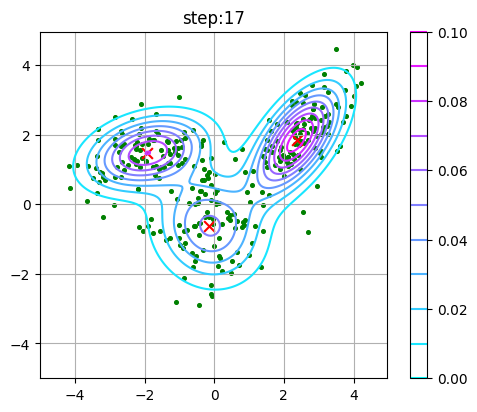

Iteration: 18, log_likelihood: -3.4384058995806597


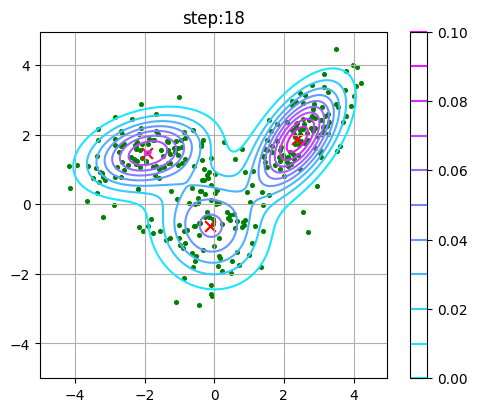

Iteration: 19, log_likelihood: -3.437318888806062


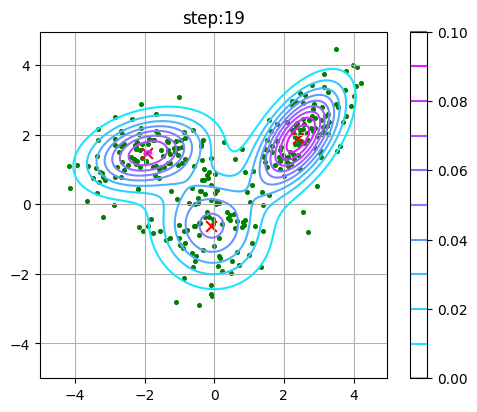

Iteration: 20, log_likelihood: -3.4365908613484355


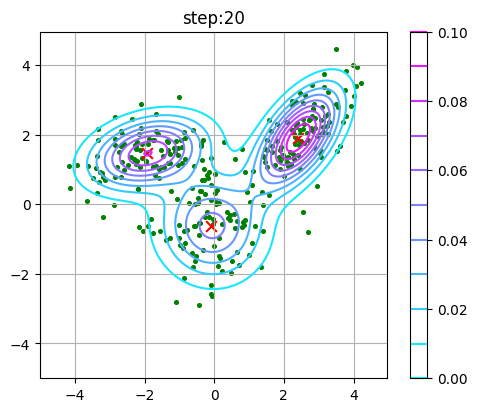

Iteration: 21, log_likelihood: -3.436111278284389


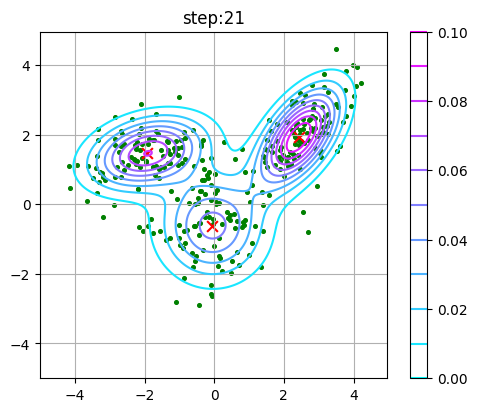

Iteration: 22, log_likelihood: -3.4357984026243726


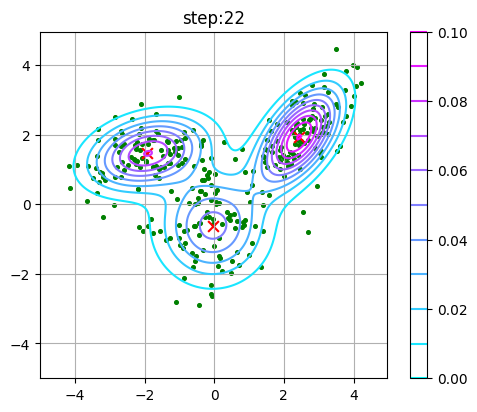

Iteration: 23, log_likelihood: -3.4355954297680316


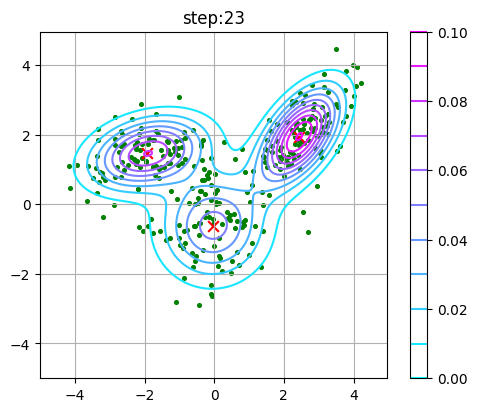

Iteration: 24, log_likelihood: -3.4354641846902765


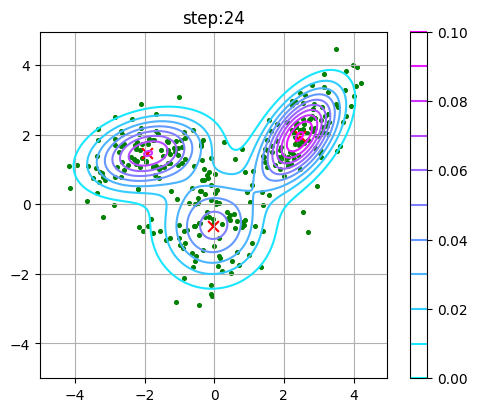

Iteration: 25, log_likelihood: -3.435379480331334


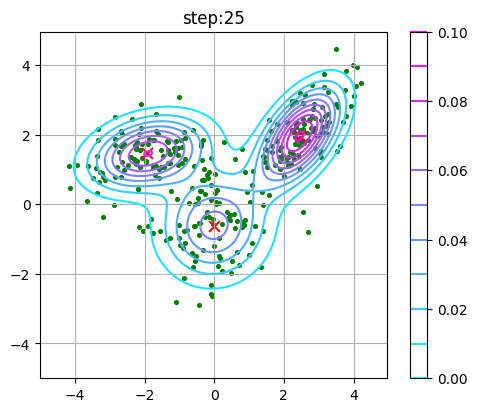

In [16]:
# パラメータ初期化 (適当な値で初期化)
mu0 = np.array([-1, -3])
sigma0 = np.array([[0.5, 0.1], [0.1, 1.5]])

mu1 = np.array([-2.5, 3.2])
sigma1 = np.array([[0.7, 0.1], [0.1, 0.5]])

mu2 = np.array([1, -1])
sigma2 = np.array([[0.8, 0.4], [0.4, 1.0]])

mu_list = [mu0, mu1, mu2]
sigma_list = [sigma0, sigma1, sigma2]
sigma_inv_list = [np.linalg.inv(sigma) for sigma in sigma_list]
sigma_det_list = [np.linalg.det(sigma) for sigma in sigma_list]
pi_list = [0.3, 0.3, 0.4]


n_iter = 0

likely = log_likelihood(data_all, mu_list, sigma_list, pi_list) / NUM_DATA
print('Iteration: {0}, log_likelihood: {1}'.format(n_iter, likely))
visualization(data_all, mu_list, sigma_inv_list, sigma_det_list)


# 下がり幅がth以下になったら収束したと判定する
th = 0.0001

# 学習
while True:
    n_iter += 1

    # Eステップ(負担率計算)
    gamma_mat = responsibility(data_all, mu_list, sigma_list, pi_list)
    n_k = np.sum(gamma_mat, axis=0)

    # Mステップ(パラメータ更新)
    # piの新しい推定量
    pi_list_next = (n_k / n_k.sum()).tolist()

    # gamma_mat: ( 3000, 3 ) data_all: ( 3000, 2 ) n_k: ( 3, )
    mu_list_next = (gamma_mat.T @ data_all) / n_k[:, np.newaxis] # ( 3, 2 )

    # muの新しい推定量
    mu_list_next = list(mu_list_next) # [( 2, ), ( 2, ), ( 2, )]

    # Sigmaの新しい推定量
    sigma_list_next = []
    for k in range(len(pi_list)):
        sigma_k = np.zeros_like(sigma_list[k], dtype=float)

        for n in range(data_all.shape[0]):
            sigma_k += gamma_mat[n][k] * np.outer(
                (data_all[n] - mu_list_next[k]),
                (data_all[n] - mu_list_next[k])
            )

        sigma_list_next.append(sigma_k/n_k[k])


    mu_list = copy.deepcopy(mu_list_next)
    sigma_list = copy.deepcopy(sigma_list_next)
    pi_list = copy.deepcopy(pi_list_next)

    sigma_inv_list = [np.linalg.inv(sigma) for sigma in sigma_list]
    sigma_det_list = [np.linalg.det(sigma) for sigma in sigma_list]

    likely_before = likely

    likely = log_likelihood(data_all, mu_list, sigma_list, pi_list) / NUM_DATA

    print('Iteration: {0}, log_likelihood: {1}'.format(n_iter, likely))

    visualization(data_all, mu_list, sigma_inv_list, sigma_det_list)

    delta = likely - likely_before
    if delta < th:
        break